# The variance of angular momentum: $\langle J^2\rangle-\langle J\rangle^2$
### why a quantum spin can never point straight at an axis

Angular momentum is three operators that refuse to commute, $[J_x,J_y]=iJ_z$, so you can't pin
down all three at once. What you *can* share are $J^2$ and one component $J_z$, with eigenstates
$|j,m\rangle$: $J^2=j(j+1)$, $J_z=m$. In such a state $J_z$ is razor-sharp ($\Delta J_z=0$) but the
other two components are **fuzzy** -- and their spread $\langle J^2\rangle-\langle J\rangle^2$
carries the whole geometry of quantum spin. Driving `dgs/angular_momentum.py`, this notebook shows:

1. the component variances $\Delta J_x^2=\langle J_x^2\rangle-\langle J_x\rangle^2$ in each state;
2. the key identity $\langle J^2\rangle-\langle J_z\rangle^2=j(j+1)-m^2>0$ -- the transverse
   spread that **never vanishes**, so $\vec J$ rides a **cone**, never the $z$-axis;
3. the angular-momentum uncertainty relation $\Delta J_x\,\Delta J_y\ge\tfrac12|\langle J_z\rangle|$,
   which the stretched state $|j,j\rangle$ **saturates**;
4. the classical limit $j\to\infty$, where the cone closes onto the axis.

(units $\hbar=1$).

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import angular_momentum as am

def expval(A, psi):   return np.real(np.vdot(psi, A @ psi))
def variance(A, psi): return expval(A @ A, psi) - expval(A, psi)**2

j = 2.0
Jx, Jy, Jz, J2 = am.jx(j), am.jy(j), am.jz(j), am.j_squared(j)
ms = am.m_values(j)
print("j =", j, "  m =", ms)
print("J^2 eigenvalue j(j+1) =", j*(j+1), " (matrix is that times I:",
      np.allclose(J2, j*(j+1)*np.eye(len(ms))), ")")

j = 2.0   m = [ 2.  1.  0. -1. -2.]
J^2 eigenvalue j(j+1) = 6.0  (matrix is that times I: True )


## 1. In $|j,m\rangle$: $J_z$ is sharp, $J_x$ and $J_y$ are fuzzy

Each basis state $|j,m\rangle$ is an eigenstate of $J_z$, so measuring $J_z$ always gives $m$
exactly ($\Delta J_z=0$). But $\langle J_x\rangle=\langle J_y\rangle=0$ with a nonzero spread
$\Delta J_x^2=\Delta J_y^2=\tfrac12\big(j(j+1)-m^2\big)$ -- the transverse components are
maximally uncertain. Compute the variances straight from the operators and compare to the
formula.

 m    <Jz>  dJz^2   <Jx>   dJx^2   formula (j(j+1)-m^2)/2
+2   +2.0   0.000  +0.00   1.000   1.000
+1   +1.0   0.000  +0.00   2.500   2.500
+0   +0.0   0.000  +0.00   3.000   3.000
-1   -1.0   0.000  +0.00   2.500   2.500
-2   -2.0   0.000  +0.00   1.000   1.000


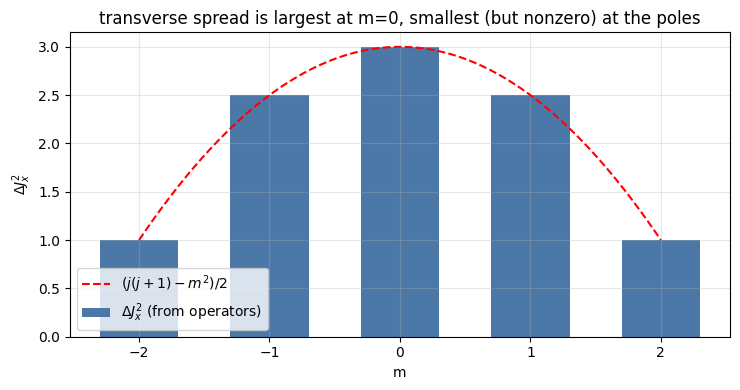

In [2]:
def basis(k, n):           # |j,m> = k-th unit vector
    e = np.zeros(n, complex); e[k] = 1.0; return e

n = len(ms)
print(" m    <Jz>  dJz^2   <Jx>   dJx^2   formula (j(j+1)-m^2)/2")
dJx2 = []
for k, m in enumerate(ms):
    psi = basis(k, n)
    vx = variance(Jx, psi); dJx2.append(vx)
    print(f"{m:+.0f}   {expval(Jz,psi):+.1f}   {variance(Jz,psi):.3f}  "
          f"{expval(Jx,psi):+.2f}   {vx:.3f}   {(j*(j+1)-m**2)/2:.3f}")

plt.figure(figsize=(7.5, 4))
plt.bar(ms, dJx2, width=0.6, color="#4C78A8", label="$\\Delta J_x^2$ (from operators)")
mm = np.linspace(-j, j, 200)
plt.plot(mm, (j*(j+1)-mm**2)/2, "r--", label="$(j(j+1)-m^2)/2$")
plt.xlabel("m"); plt.ylabel("$\\Delta J_x^2$")
plt.title("transverse spread is largest at m=0, smallest (but nonzero) at the poles")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 2. The identity that forbids alignment: $\langle J^2\rangle-\langle J_z\rangle^2=j(j+1)-m^2$

Here is the heart of it. $\langle J^2\rangle=j(j+1)$ but $\langle J_z\rangle^2=m^2$, and the gap
$$\langle J^2\rangle-\langle J_z\rangle^2=\langle J_x^2+J_y^2\rangle=j(j+1)-m^2$$
is **strictly positive for every state** -- even the top rung $m=j$ leaves a residue $j(j+1)-j^2=j$.
So $|\vec J|=\sqrt{j(j+1)}$ always exceeds its largest possible $z$-projection $j$: the spin can
tilt toward the axis but never lie on it. The angle it makes is $\cos\theta=m/\sqrt{j(j+1)}$.

In [3]:
gap = [expval(J2, basis(k,n)) - expval(Jz, basis(k,n))**2 for k in range(n)]
print(" m   <J^2>-<Jz>^2   j(j+1)-m^2   cos(theta)=m/sqrt(j(j+1))")
for k, m in enumerate(ms):
    print(f"{m:+.0f}    {gap[k]:.3f}        {j*(j+1)-m**2:.3f}       {m/np.sqrt(j*(j+1)):+.3f}")
print("\nlength |J| = sqrt(j(j+1)) =", round(np.sqrt(j*(j+1)),3),
      " >  max projection m=j =", j, " -> never fully aligned")

 m   <J^2>-<Jz>^2   j(j+1)-m^2   cos(theta)=m/sqrt(j(j+1))
+2    2.000        2.000       +0.816
+1    5.000        5.000       +0.408
+0    6.000        6.000       +0.000
-1    5.000        5.000       -0.408
-2    2.000        2.000       -0.816

length |J| = sqrt(j(j+1)) = 2.449  >  max projection m=j = 2.0  -> never fully aligned


## 3. The vector-model cones

Picture it. $\vec J$ has fixed length $\sqrt{j(j+1)}$ and a definite height $m$, but its
transverse part points *nowhere in particular* -- $\langle J_x\rangle=\langle J_y\rangle=0$ with
spread $\sqrt{(j(j+1)-m^2)/2}$ each. So the tip is smeared around a **circle** of radius
$\sqrt{j(j+1)-m^2}$ at height $m$: a cone. One cone per $m$, none of them closed onto the axis.

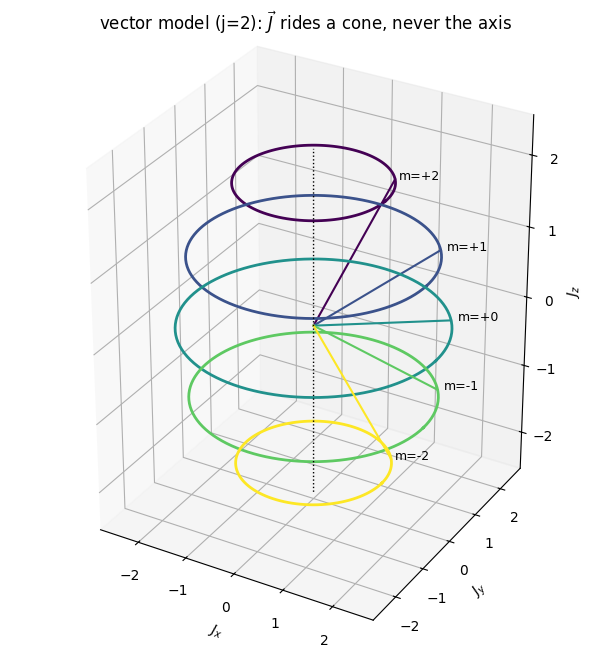

In [4]:
fig = plt.figure(figsize=(6.5, 6.5)); ax = fig.add_subplot(111, projection="3d")
R = np.sqrt(j*(j+1)); phi = np.linspace(0, 2*np.pi, 120)
colors = plt.cm.viridis(np.linspace(0, 1, n))
for k, m in enumerate(ms):
    r = np.sqrt(j*(j+1) - m**2)
    ax.plot(r*np.cos(phi), r*np.sin(phi), m*np.ones_like(phi), color=colors[k], lw=2)
    ax.plot([0, r*np.cos(0.6)], [0, r*np.sin(0.6)], [0, m], color=colors[k], lw=1.5)
    ax.text(r*np.cos(0.6)*1.05, r*np.sin(0.6)*1.05, m, f"m={m:+.0f}", fontsize=9)
ax.plot([0,0],[0,0],[-R,R], "k:", lw=1)
ax.set_xlabel("$J_x$"); ax.set_ylabel("$J_y$"); ax.set_zlabel("$J_z$")
ax.set_title("vector model (j=2): $\\vec J$ rides a cone, never the axis")
ax.set_box_aspect((1,1,1.3)); plt.tight_layout(); plt.show()

## 4. The uncertainty relation -- and the state that saturates it

The non-commuting $[J_x,J_y]=iJ_z$ forces $\Delta J_x\,\Delta J_y\ge\tfrac12|\langle J_z\rangle|
=\tfrac12|m|$. In $|j,m\rangle$ the left side is $\tfrac12(j(j+1)-m^2)$. The two are equal exactly at
the **stretched states** $m=\pm j$: $\tfrac12(j(j+1)-j^2)=\tfrac12 j=\tfrac12|m|$. So $|j,j\rangle$
is the minimum-uncertainty spin state -- the closest a quantum $\vec J$ ever gets to a definite
direction, the spin analogue of a coherent state.

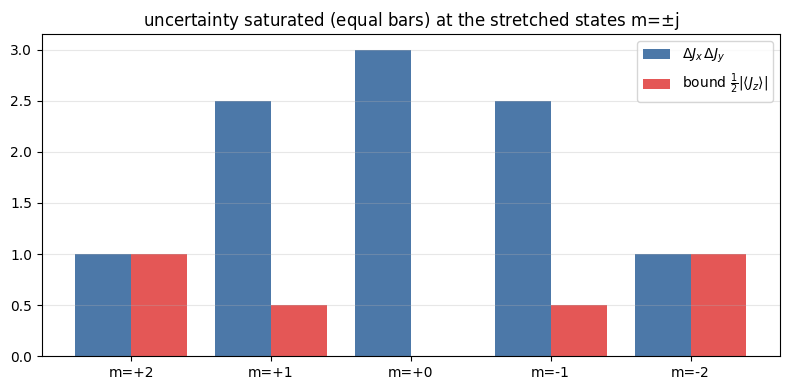

saturated at m=+-j: True


In [5]:
lhs = [np.sqrt(variance(Jx, basis(k,n))*variance(Jy, basis(k,n))) for k in range(n)]
bound = [0.5*abs(expval(Jz, basis(k,n))) for k in range(n)]
x = np.arange(n)
plt.figure(figsize=(8, 4))
plt.bar(x-0.2, lhs, 0.4, label="$\\Delta J_x\\,\\Delta J_y$", color="#4C78A8")
plt.bar(x+0.2, bound, 0.4, label="bound $\\frac{1}{2}|\\langle J_z\\rangle|$", color="#E45756")
plt.xticks(x, [f"m={m:+.0f}" for m in ms])
plt.title("uncertainty saturated (equal bars) at the stretched states m=$\\pm$j")
plt.legend(); plt.grid(alpha=0.3, axis="y"); plt.tight_layout(); plt.show()
print("saturated at m=+-j:", np.allclose(lhs[0], bound[0]) and np.allclose(lhs[-1], bound[-1]))

## 5. The classical limit: big $j$ closes the cone

For the top state, $\cos\theta_{\min}=j/\sqrt{j(j+1)}$. As $j$ grows this $\to 1$, the cone
half-angle $\to 0$, and the relative transverse fuzz $\sqrt{j}/j\to 0$: a large spin *can* point
(almost) along the axis -- classical angular momentum re-emerging from the algebra.

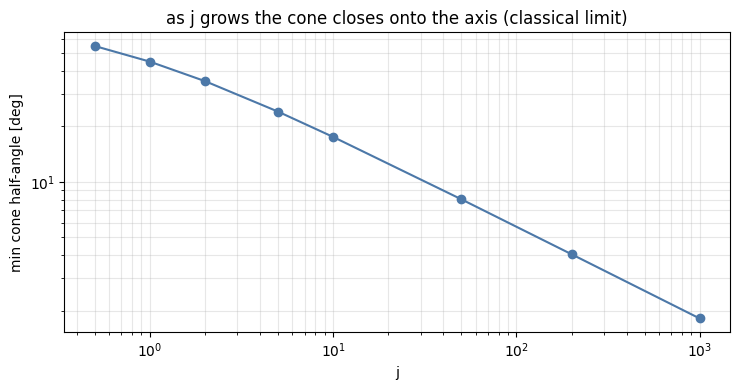

qubit j=1/2: theta_min = 54.7 deg (54.7, wide open) ;  j=1000: 1.81 deg


In [6]:
js = np.array([0.5, 1, 2, 5, 10, 50, 200, 1000], float)
theta_min = np.degrees(np.arccos(js/np.sqrt(js*(js+1))))
plt.figure(figsize=(7.5, 4))
plt.loglog(js, theta_min, "o-", color="#4C78A8")
plt.xlabel("j"); plt.ylabel("min cone half-angle [deg]")
plt.title("as j grows the cone closes onto the axis (classical limit)")
plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()
print("qubit j=1/2: theta_min = %.1f deg (54.7, wide open) ;  j=1000: %.2f deg"
      % (theta_min[0], theta_min[-1]))

## What we did

* In $|j,m\rangle$, $J_z$ is sharp but $\Delta J_x^2=\Delta J_y^2=\tfrac12(j(j+1)-m^2)$ -- the
  transverse components are maximally uncertain.
* $\langle J^2\rangle-\langle J_z\rangle^2=j(j+1)-m^2>0$ **always**, so $|\vec J|=\sqrt{j(j+1)}$
  exceeds its top projection $j$: the spin rides a **cone**, never the axis.
* $\Delta J_x\,\Delta J_y\ge\tfrac12|\langle J_z\rangle|$, saturated by the stretched state
  $|j,j\rangle$ (the minimum-uncertainty spin).
* Large $j$ closes the cone -- the classical vector returns.

Same $\langle A^2\rangle-\langle A\rangle^2$ spread as `notebooks/uncertainty_in_observables.ipynb`
(there for $x,p$; here for spin), and the same ladder structure as `dgs/quantum_oscillator.py`.
At $j=\tfrac12$ these operators are the Pauli matrices -- the qubit's angular momentum.